In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle
import pandas as pd
from pathlib import Path
import sys

ROOT =  Path().resolve().parent
sys.path.append(str(ROOT))

import globals as gl

plt.style.use('default')

Base directory found: /Users/mnlmrc/Library/CloudStorage/GoogleDrive-mnlmrc@unife.it/My Drive/UWO/SensoriMotorPrediction/
Base directory: /Users/mnlmrc/Library/CloudStorage/GoogleDrive-mnlmrc@unife.it/My Drive/UWO/SensoriMotorPrediction/
Atlases dir found: /Users/mnlmrc/Documents/GitHub/sensori-motor-prediction/data/atlases


In [3]:
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp']
H = 'L'
experiment = 'smp2'
corr = 'plan-exec'

SMA: r=-0.999999970308918, [-1.0, -0.9999998883350512]
PMd: r=-0.3579002187218182, [-0.6492387065504953, -0.1704002337599419]
PMv: r=-1.0, [-1.0, -0.56557655250766]
M1: r=0.6329187001514598, [0.5155387284543114, 0.7132559202414935]
S1: r=0.6115209015521293, [0.4679249504618107, 0.7281171274922129]
SPLa: r=-0.7898913905838213, [-1.0, -0.5926211488273626]
SPLp: r=-1.0, [-1.0, -0.7033258386157634]


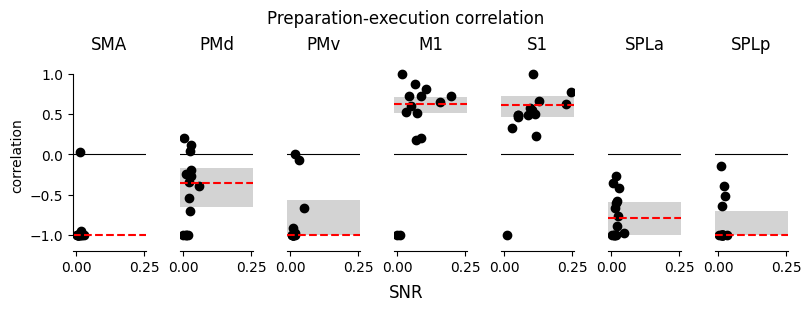

In [4]:
df_corr = pd.read_csv(os.path.join(ROOT, 'data','correlations', 'correlations.BOLD.tsv'), sep='\t')

fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, figsize=(8, 3), constrained_layout=True)

for r, roi in enumerate(rois):
    ax = axs[r]
    df_corr_tmp = df_corr[(df_corr['roi'] == roi) & (df_corr['Hem'] == H) & (df_corr['corr'] == corr)]
    r_indiv = df_corr_tmp.r_indiv.to_numpy()
    SNR = df_corr_tmp.SNR.to_numpy()
    r_group = df_corr_tmp.r_group.to_numpy()[0]
    ci_lo, ci_hi = df_corr_tmp.ci_lo.to_numpy()[0], df_corr_tmp.ci_hi.to_numpy()[0]
    print(f'{roi}: r={r_group}, [{ci_lo}, {ci_hi}]')
    ax.scatter(SNR, r_indiv, color='k')
    ax.axhline(r_group, color='r', linestyle='--')
    ax.axhline(0, color='k', linestyle='-', lw=.8)
    ax.axhspan(ci_lo, ci_hi, lw=0, color='lightgrey', zorder=0)
    ax.set_ylim(-1.2, 1.2)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    if r == 0:
        ax.spines[['left']].set_visible(True)
        ax.spines['left'].set_bounds(-1, 1)
    else:
        ax.tick_params(left=False)
    ax.set_title(roi)

fig.supxlabel('SNR')
axs[0].set_ylabel('correlation')

fig.suptitle(f'Preparation-execution correlation')

plt.show()
